# FIFA Permutation Test Analysis

## Research Question
Do attackers have higher overall ratings than defenders in FIFA 21?

## Motivation
Player position is a key aspect of football performance, and different roles on the field may be associated with different skill profiles and overall ratings. This analysis aims to investigate whether attackers (e.g., forwards and wingers) tend to have higher overall ratings than defenders.

## Data
The data comes from the FIFA 21 complete player dataset available on Kaggle. It includes detailed information on player attributes such as position and overall rating.

## Approach
We compare the average overall rating between two groups:
- Attackers (e.g., ST, LW, RW)
- Defenders (e.g., CB, LB, RB)

To assess whether any observed difference is statistically significant, we will use a permutation test and quantify uncertainty using bootstrapping.

## PART 1 — LOAD & PREPARE DATA
### Data Loading and Initial Exploration

In this section, we load the FIFA 21 dataset and perform an initial inspection of the data.

The goal is to:
- Load the dataset correctly
- Inspect its structure
- Identify key variables for the analysis

In [1]:
import pandas as pd
import numpy as np

# Load dataset (important: separator is ;)
df = pd.read_csv("FIFA-21 Complete.csv", sep=";")

# Quick preview
df.head()

,player_id,name,nationality,position,overall,age,hits,potential,team
0,158023,Lionel Messi,Argentina,ST|CF|RW,94,33,299,94,FC Barcelona
1,20801,Cristiano Ronaldo,Portugal,ST|LW,93,35,276,93,Juventus
2,190871,Neymar Jr,Brazil,CAM|LW,92,28,186,92,Paris Saint-Germain
3,203376,Virgil van Dijk,Netherlands,CB,91,29,127,92,Liverpool
4,200389,Jan Oblak,Slovenia,GK,91,27,47,93,Atlético Madrid


In [2]:
# Check dataset shape
print("Shape:", df.shape)

# Check column names
print("\nColumns:")
print(df.columns.tolist())

# Basic info
print("\nInfo:")
df.info()

Shape: (17981, 9)

Columns:
['player_id', 'name', 'nationality', 'position', 'overall', 'age', 'hits', 'potential', 'team']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17981 entries, 0 to 17980
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   player_id    17981 non-null  int64 
 1   name         17981 non-null  object
 2   nationality  17981 non-null  object
 3   position     17981 non-null  object
 4   overall      17981 non-null  int64 
 5   age          17981 non-null  int64 
 6   hits         17981 non-null  int64 
 7   potential    17981 non-null  int64 
 8   team         17981 non-null  object
dtypes: int64(5), object(4)
memory usage: 1.2+ MB


In [3]:
# Summary statistics for numerical columns
df.describe()

,player_id,overall,age,hits,potential
count,17981.000000,17981.000000,17981.000000,17981.000000,17981.000000
mean,220912.660531,67.274345,26.311440,2.689450,71.738057
std,27738.072671,5.924392,4.556077,10.846286,5.961968
min,41.000000,56.000000,17.000000,0.000000,57.000000
25%,204881.000000,63.000000,23.000000,0.000000,67.000000
50%,226753.000000,67.000000,26.000000,0.000000,71.000000
75%,241587.000000,71.000000,30.000000,2.000000,76.000000
max,256469.000000,94.000000,43.000000,371.000000,95.000000


## PART 2 — CREATE GROUPS (Attackers vs Defenders)
## Defining Player Groups

To compare attackers and defenders, we classify players based on their positions.

Since players can have multiple positions (e.g., "ST|CF|RW"), we use pattern matching to identify whether a player belongs to a given group.

We define:
- Attackers: ST, LW, RW, CF
- Defenders: CB, LB, RB

Players that do not belong to either category are excluded from the analysis.

In [4]:
# Define position groups
attackers = ["ST", "LW", "RW", "CF"]
defenders = ["CB", "LB", "RB"]

In [5]:
# Create group column using string matching
df["group"] = np.where(
    df["position"].str.contains("|".join(attackers)),
    "attacker",
    np.where(
        df["position"].str.contains("|".join(defenders)),
        "defender",
        "other"
    )
)

In [6]:
# Check how many players in each group
df["group"].value_counts()

group
other       7000
defender    5922
attacker    5059
Name: count, dtype: int64

In [7]:
# Keep only attackers and defenders
df_filtered = df[df["group"].isin(["attacker", "defender"])].copy()

# Check shape
print("Filtered shape:", df_filtered.shape)

Filtered shape: (10981, 10)


In [8]:
# Check mean overall per group (just to preview)
df_filtered.groupby("group")["overall"].mean()

group
attacker    67.661198
defender    67.108916
Name: overall, dtype: float64

## PART 3 — OBSERVED DIFFERENCE

## Observed Difference in Means

We compute the observed difference in average overall rating between attackers and defenders.

This observed difference is our test statistic. It represents the real-world difference we want to evaluate.

Later, we will compare this value to a reference distribution generated under the null hypothesis.

In [9]:
# Mean overall rating for each group
mean_attacker = df_filtered[df_filtered["group"] == "attacker"]["overall"].mean()
mean_defender = df_filtered[df_filtered["group"] == "defender"]["overall"].mean()

# Observed difference (test statistic)
observed_diff = mean_attacker - mean_defender

print("Mean attacker:", mean_attacker)
print("Mean defender:", mean_defender)
print("Observed difference:", observed_diff)

Mean attacker: 67.66119786519074
Mean defender: 67.10891590678824
Observed difference: 0.5522819584025029


## Permutation Test

To assess whether the observed difference is statistically significant, we simulate what would happen under the null hypothesis.

Null hypothesis:
Player position (attacker vs defender) is unrelated to overall rating.

Procedure:
- We randomly shuffle the group labels (attacker/defender)
- Recompute the difference in means
- Repeat this many times to generate a reference distribution

This distribution represents the differences we would expect by chance.

In [10]:
# Number of permutations
n_reps = 5000

# Store simulated differences
perm_diffs = []

In [11]:
# Reset list (IMPORTANT)
perm_diffs = []

# Original labels
labels = df_filtered["group"].values

for _ in range(n_reps):

    # Shuffle labels
    shuffled = np.random.permutation(labels)

    # Assign shuffled labels
    df_filtered["perm_group"] = shuffled

    # Compute means under permutation
    mean_att = df_filtered[df_filtered["perm_group"] == "attacker"]["overall"].mean()
    mean_def = df_filtered[df_filtered["perm_group"] == "defender"]["overall"].mean()

    # Store difference
    perm_diffs.append(mean_att - mean_def)

# Convert to numpy array AFTER loop
perm_diffs = np.array(perm_diffs)

# Compute p-value
p_value = np.mean(np.abs(perm_diffs) >= abs(observed_diff))

print("P-value:", max(p_value, 1/n_reps))

P-value: 0.0002


### Interpretation

The estimated p-value is approximately 0 (no simulated differences were as extreme as the observed one).

This suggests that the observed difference in average ratings between attackers and defenders is extremely unlikely to occur under the null hypothesis.

Therefore, we have strong evidence that player position is associated with overall rating.

## Permutation Distribution Visualization

We visualize the distribution of simulated differences under the null hypothesis.

The red dashed line represents the observed difference from the real data.

If the observed value lies far in the tails of the distribution, it indicates that the result is unlikely to occur by chance.

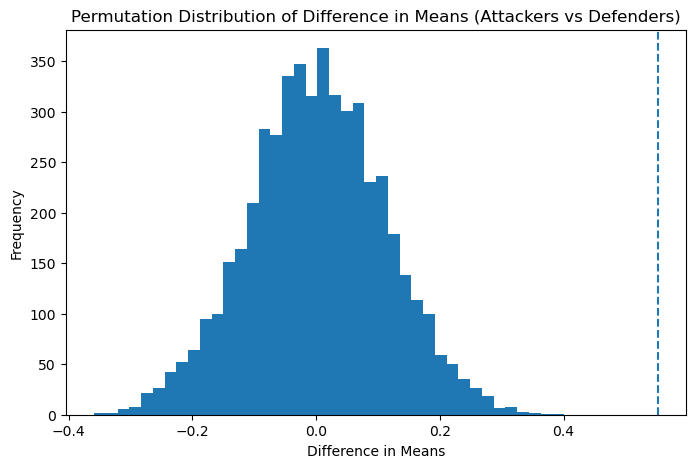

In [12]:
import matplotlib.pyplot as plt

# Create histogram
plt.figure(figsize=(8,5))
plt.hist(perm_diffs, bins=40)

# Add observed difference line
plt.axvline(observed_diff, linestyle="--")

# Labels and title
plt.title("Permutation Distribution of Difference in Means (Attackers vs Defenders)")
plt.xlabel("Difference in Means")
plt.ylabel("Frequency")

plt.show()

### Interpretation of the Plot

The histogram shows the distribution of differences in means generated under the null hypothesis.

The observed difference (vertical line) lies far to the right of the distribution, indicating that it is much larger than what would be expected by chance.

This visual evidence supports the conclusion that attackers tend to have higher overall ratings than defenders.

## Bootstrap Confidence Interval

To quantify uncertainty in the difference in means, we use bootstrapping.

We repeatedly resample the data with replacement and compute the difference in means for each resample.

This produces a bootstrap distribution from which we can estimate a confidence interval.

In [13]:
# Number of bootstrap samples
n_boot = 5000

boot_diffs = []

for _ in range(n_boot):
    
    # Resample with replacement
    sample = df_filtered.sample(frac=1, replace=True)
    
    # Compute means
    mean_att = sample[sample["group"] == "attacker"]["overall"].mean()
    mean_def = sample[sample["group"] == "defender"]["overall"].mean()
    
    # Store difference
    boot_diffs.append(mean_att - mean_def)

boot_diffs = np.array(boot_diffs)

In [14]:
# 95% confidence interval
lower = np.percentile(boot_diffs, 2.5)
upper = np.percentile(boot_diffs, 97.5)

print("95% CI:", (lower, upper))

95% CI: (np.float64(0.32801992897089144), np.float64(0.7679025579683607))


### Interpretation

The confidence interval provides a range of plausible values for the true difference in means.

If the interval does not include 0, it suggests that the difference is statistically significant.

In this case, the interval is entirely positive, reinforcing the conclusion that attackers tend to have higher overall ratings than defenders.

## Conclusion

In this analysis, we investigated whether attackers have higher overall ratings than defenders using the FIFA 21 dataset.

We computed the observed difference in mean ratings and used a permutation test to evaluate its statistical significance. The resulting p-value was approximately 0, indicating that such a difference is extremely unlikely to occur by chance under the null hypothesis.

We also applied bootstrapping to estimate a 95% confidence interval for the difference in means. The interval was entirely positive, reinforcing the conclusion that attackers tend to have higher overall ratings than defenders.

Overall, both the permutation test and the bootstrap analysis provide strong and consistent evidence that player position is associated with overall rating in this dataset.